# **CS4120 Project: Analyzing Bias in Different Cuisine Type Restaurant Reviews (Yelp)**

### Melina Yang, Arpitha Coorg, Sheryl Cheng

## Yelp Restaurant & Cuisine Preprocessing

Filter businesses to restaurants, assign ethnic cuisine labels, merge reviews in chunks, balance samples, clean text, and export baseline data.

In [1]:
# imports
import gc
import os
import re
from pathlib import Path
import pandas as pd

In [2]:
# global variables
business_data = "yelp_academic_dataset_business.json"
review_data = "yelp_academic_dataset_review.json"

output_csv = "processed_reviews_baseline.csv"

review_chunk_size = 50_000
max_per_cuisine = 10_000
sample_random_state = 42

### Filter for restaurants only

Keep businesses whose `categories` string contains **Restaurants** (case-insensitive).

In [3]:
business_all = pd.read_json(business_data, lines=True)
n_business_total = len(business_all)

# case-insensitive: categories string must contain "Restaurants"
cat_mask = business_all["categories"].str.contains(
    "Restaurants", case=False, na=False, regex=False
)
business_rest = business_all.loc[cat_mask].copy()
n_restaurants = len(business_rest)

del business_all
gc.collect()

FileNotFoundError: File yelp_academic_dataset_business.json does not exist

### Assign cuisine types

Match comma-separated `categories` against keywords; first cuisine in the fixed priority order wins.

In [ ]:
# order matters: first matching cuisine in this list is assigned.
cuisine_mapping = [
    ("Chinese", ["Chinese", "Cantonese", "Szechuan", "Dim Sum"]),
    ("Japanese", ["Japanese", "Sushi", "Ramen", "Izakaya"]),
    ("Korean", ["Korean"]),
    ("Thai", ["Thai"]),
    ("Vietnamese", ["Vietnamese", "Pho"]),
    ("Indian", ["Indian", "Pakistani", "Bangladeshi", "Himalayan"]),
    ("Mexican", ["Mexican", "Tex-Mex"]),
    ("Italian", ["Italian"]),
    (
        "American",
        ["American (Traditional)", "American (New)", "Burgers"],
    ),
    ("French", ["French"]),
]


def assign_cuisine_type(categories) -> str:
    """
    If any keyword appears in the categories string (case-insensitive),
    return the first matching cuisine in cuisine_mapping order.
    Otherwise return 'Other'.
    """
    if pd.isna(categories) or not str(categories).strip():
        return "Other"
    text = str(categories).lower()
    for cuisine, keywords in cuisine_mapping:
        for kw in keywords:
            if kw.lower() in text:
                return cuisine
    return "Other"


business_rest["cuisine_type"] = business_rest["categories"].map(assign_cuisine_type)

### Merge reviews with restaurant businesses (chunked)

Inner-merge each review chunk on `business_id`. Keep only rows where `cuisine_type != 'Other'`.

In [ ]:
# slim lookup table for merges
biz_cols = ["business_id", "cuisine_type", "name", "city", "state"]
biz_lookup = business_rest[biz_cols].drop_duplicates(subset=["business_id"])
del business_rest
gc.collect()

review_keep = ["review_id", "user_id", "business_id", "stars", "text", "date"]
merge_cols = review_keep + ["cuisine_type", "name", "city", "state"]

merged_chunks: list[pd.DataFrame] = []

for i, chunk in enumerate(
    pd.read_json(review_data, lines=True, chunksize=review_chunk_size)
):
    chunk = chunk[review_keep]
    m = chunk.merge(biz_lookup, on="business_id", how="inner")
    m = m.loc[m["cuisine_type"] != "Other", merge_cols]
    if len(m) > 0:
        merged_chunks.append(m)

reviews_merged = pd.concat(merged_chunks, ignore_index=True)
del merged_chunks
gc.collect()

del biz_lookup
gc.collect()

0

### Balance: up to 10,000 reviews per cuisine

In [ ]:
balanced_parts: list[pd.DataFrame] = []
for cuisine, g in reviews_merged.groupby("cuisine_type"):
    n = min(max_per_cuisine, len(g))
    balanced_parts.append(g.sample(n=n, random_state=sample_random_state))

balanced = pd.concat(balanced_parts, ignore_index=True)
del balanced_parts

del reviews_merged
gc.collect()

0

### Basic text cleaning and length filter

Lowercase, strip URLs, normalize whitespace; drop reviews with fewer than 10 words.

In [ ]:
# match http(s) URLs and common www. spans
url_pattern = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
whitespace_pattern = re.compile(r"\s+")


def clean_review_text(text: str) -> str:
    if pd.isna(text):
        return ""
    t = str(text).lower()
    t = url_pattern.sub(" ", t)
    t = whitespace_pattern.sub(" ", t).strip()
    return t


balanced["text_clean"] = balanced["text"].map(clean_review_text)
balanced["word_count"] = balanced["text_clean"].str.split().str.len().fillna(0).astype(int)
balanced = balanced.loc[balanced["word_count"] >= 10].copy()
balanced = balanced.drop(columns=["word_count"])

### Save processed reviews CSV

In [ ]:
save_cols = [
    "review_id",
    "user_id",
    "business_id",
    "stars",
    "text",
    "text_clean",
    "date",
    "cuisine_type",
    "name",
    "city",
    "state",
]
balanced[save_cols].to_csv(output_csv, index=False)

---

## Baseline Sentiment Analysis

Load `processed_reviews_baseline.csv`, score with VADER, then summarize by cuisine and run correlation / ANOVA / pairwise tests.


In [ ]:
# imports and downloads for nltk/vader
import os
import urllib.request
import zipfile
import ssl

# bypass SSL verification
ssl._create_default_https_context = ssl._create_unverified_context

# create directory
os.makedirs('nltk_data/sentiment', exist_ok=True)

# download nltk vader lexicon
url = 'https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/sentiment/vader_lexicon.zip'
zip_path = 'nltk_data/sentiment/vader_lexicon.zip'
urllib.request.urlretrieve(url, zip_path)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('nltk_data/sentiment/')
    
import nltk
nltk.data.path.insert(0, './nltk_data')
from nltk.sentiment import SentimentIntensityAnalyzer

In [ ]:
# other imports
import pandas as pd
import numpy as np
from scipy import stats as scipy_stats
from itertools import combinations

### Load preprocessed data

In [ ]:
df_sent = pd.read_csv("processed_reviews_baseline.csv")
display(df_sent.head(3))

,review_id,user_id,business_id,stars,text,text_clean,date,cuisine_type,name,city,state
0,of7o9WvF69sGcVVtv88v_Q,5o8TESbKhlQFRib6L0DHZQ,IDXLt6-LwcJTIFtKRJhW3g,5,"Exquisite staff; such a wonderful, perfect com...","exquisite staff; such a wonderful, perfect com...",2015-12-31 03:26:03,American,OTB Delight Café,Wesley Chapel,FL
1,uaSEIH9-3uW3YQwtMDnjMQ,ORZtHt-cu7GB83YtvT5iQw,AcGOk0jbFkvI1QzDpkqA8w,1,They never text me back I've been waiting for ...,they never text me back i've been waiting for ...,2019-02-23 05:59:13,American,The Rusty Lyon,Dunedin,FL
2,kE5U8qhhfKoYveEW6cRfDw,nJEvAVx0yYuF1pN3IinDiw,2hErWx-q_Ixx6zYgQMPw7g,5,Mangroves is one of the nicest restaurants in ...,mangroves is one of the nicest restaurants in ...,2013-05-29 14:43:33,American,Mangroves,Tampa,FL


### Apply VADER sentiment analysis

In [ ]:
sia = SentimentIntensityAnalyzer()

texts = df_sent["text_clean"].fillna("").astype(str)
n = len(texts)
neg, neu, pos, compound = [], [], [], []

for i, t in enumerate(texts):
    scores = sia.polarity_scores(t)
    neg.append(scores["neg"])
    neu.append(scores["neu"])
    pos.append(scores["pos"])
    compound.append(scores["compound"])

df_sent["vader_negative"] = neg
df_sent["vader_neutral"] = neu
df_sent["vader_positive"] = pos
df_sent["vader_compound"] = compound

### Basic statistics by cuisine

In [ ]:
stat_cols = ["stars", "vader_compound"]

by_cuisine = df_sent.groupby("cuisine_type")[stat_cols].agg(
    ["mean", "std", "min", "max", "count"]
)
by_cuisine.columns = [f"{a}_{b}" for a, b in by_cuisine.columns]
by_cuisine = by_cuisine.reset_index()

display(by_cuisine.sort_values("stars_mean", ascending=False).reset_index(drop=True))

,cuisine_type,stars_mean,stars_std,stars_min,stars_max,stars_count,vader_compound_mean,vader_compound_std,vader_compound_min,vader_compound_max,vader_compound_count
0,Korean,4.068464,1.200261,1,5,9976,0.743115,0.454501,-0.9958,0.9997,9976
1,French,4.000000,1.270256,1,5,9979,0.755470,0.458447,-0.9975,0.9996,9979
2,Thai,3.994789,1.260583,1,5,9979,0.734423,0.462773,-0.9935,0.9997,9979
3,Indian,3.994387,1.325664,1,5,9977,0.706916,0.498712,-0.9946,0.9996,9977
4,Vietnamese,3.986956,1.249197,1,5,9966,0.712305,0.481700,-0.9950,0.9994,9966
5,Japanese,3.840557,1.361453,1,5,9991,0.690126,0.513289,-0.9937,0.9997,9991
6,Italian,3.775195,1.403816,1,5,9982,0.674218,0.531820,-0.9961,0.9997,9982
7,Mexican,3.745067,1.426353,1,5,9983,0.648945,0.548993,-0.9944,0.9997,9983
8,American,3.738878,1.389679,1,5,9980,0.679517,0.526145,-0.9938,0.9997,9980
9,Chinese,3.662355,1.434497,1,5,9972,0.617262,0.565995,-0.9994,0.9998,9972


### Sentiment-rating correlation

In [ ]:
# overall Pearson r
mask = df_sent["vader_compound"].notna() & df_sent["stars"].notna()
r_all, p_all = scipy_stats.pearsonr(
    df_sent.loc[mask, "vader_compound"],
    df_sent.loc[mask, "stars"],
)
print(f"Overall Pearson r (vader_compound vs stars): r = {r_all:.4f}, p = {p_all:.2e}")

# Pearson r per cuisine
rows = []
for cuisine, g in df_sent.groupby("cuisine_type"):
    m = g["vader_compound"].notna() & g["stars"].notna()
    if m.sum() < 3:
        rows.append(
            {
                "cuisine_type": cuisine,
                "pearson_r": np.nan,
                "p_value": np.nan,
                "n": int(m.sum()),
                "note": "insufficient rows",
            }
        )
        continue
    r_c, p_c = scipy_stats.pearsonr(g.loc[m, "vader_compound"], g.loc[m, "stars"])
    rows.append(
        {
            "cuisine_type": cuisine,
            "pearson_r": r_c,
            "p_value": p_c,
            "n": int(m.sum()),
        }
    )

corr_by_cuisine = pd.DataFrame(rows)
display(corr_by_cuisine)

Overall Pearson r (vader_compound vs stars): r = 0.6318, p = 0.00e+00


,cuisine_type,pearson_r,p_value,n
0,American,0.627819,0.0,9980
1,Chinese,0.651069,0.0,9972
2,French,0.583260,0.0,9979
3,Indian,0.661729,0.0,9977
4,Italian,0.637719,0.0,9982
5,Japanese,0.634376,0.0,9991
6,Korean,0.591619,0.0,9976
7,Mexican,0.657713,0.0,9983
8,Thai,0.616529,0.0,9979
9,Vietnamese,0.607751,0.0,9966


### ANOVA: star ratings across cuisines

In [ ]:
groups = [
    g["stars"].values
    for _, g in df_sent.groupby("cuisine_type", sort=True)
    if len(g) >= 2
]
f_stat, p_anova = scipy_stats.f_oneway(*groups)

print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value:     {p_anova:.2e}")

### Pairwise t-tests on stars

In [ ]:
cuisine_levels = sorted(df_sent["cuisine_type"].unique())
pair_rows = []
for c1, c2 in combinations(cuisine_levels, 2):
    a = df_sent.loc[df_sent["cuisine_type"] == c1, "stars"]
    b = df_sent.loc[df_sent["cuisine_type"] == c2, "stars"]
    t_stat, p_val = scipy_stats.ttest_ind(a, b, equal_var=False)
    mean_diff = float(a.mean() - b.mean())
    pair_rows.append(
        {
            "cuisine_a": c1,
            "cuisine_b": c2,
            "mean_diff_a_minus_b": mean_diff,
            "t_statistic": float(t_stat),
            "p_value": float(p_val),
            "abs_mean_diff": abs(mean_diff),
        }
    )

pair_df = pd.DataFrame(pair_rows)
top10 = pair_df.nlargest(10, "abs_mean_diff")

cols_show = [
    "cuisine_a",
    "cuisine_b",
    "mean_diff_a_minus_b",
    "p_value",
    "t_statistic",
]
display(top10[cols_show])

In [ ]:
df_sent.to_csv("processed_reviews_with_sentiment.csv", index=False)

---

## Word Frequency and Stereotype Word Analysis

Analyze stereotype-word mentions and top word frequencies by cuisine.

In [ ]:
import numpy as np
import pandas as pd
import re
from collections import Counter
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

In [ ]:
word_df = pd.read_csv("processed_reviews_with_sentiment.csv")

### Define restaurant review stereotype word categories

In [ ]:
# this was a gathered list from many sources off the internet and public opinion
stereotype_words = {
    "cheap": ["cheap", "inexpensive", "affordable", "budget"],
    "expensive": ["expensive", "pricey", "overpriced", "costly"],
    "authentic": ["authentic", "traditional", "genuine", "real", "old-school", "old school"],
    "dirty": ["dirty", "grimy", "filthy", "unsanitary", "gross"],
    "clean": ["clean", "spotless", "sanitary", "hygienic"],
    "exotic": ["exotic", "strange", "weird", "unusual"],
    "fresh": ["fresh", "quality"],
    "greasy": ["greasy", "oily"],
    "hidden_gem": ["hidden gem", "hole in the wall"],
    "must_try_hype": ["must-try", "must try", "to die for", "best ever", "best i've ever", "best i have ever"],
    "homestyle": ["homemade", "home-style", "homestyle"],
    "negative_texture": ["stale", "cold", "chewy", "rubber", "rubbery", "watery", "bland", "disappointing"],
    "luxury_sensual": ["decadent", "sensual", "sexy", "voluptuous", "voluptuously", "hedonistic", "divine", "transcendent"],
    "atmosphere_positive": ["cozy", "intimate", "buzzy", "romantic"],
    "atmosphere_negative": ["loud", "stuffy"],
    "kitschy_authenticity": ["plastic stools", "dirt floors", "kitschy"],
}

### Count stereotype word occurrences

In [ ]:
text_series = word_df["text_clean"].fillna("").astype(str)
cuisines_sorted = sorted(word_df["cuisine_type"].dropna().unique().tolist())

records = []

for cuisine in cuisines_sorted:
    c_mask = word_df["cuisine_type"] == cuisine
    c_text = text_series.loc[c_mask]
    total = int(c_mask.sum())

    for category, words in stereotype_words.items():
        if total == 0:
            count = 0
            frequency = 0.0
        else:
            escaped = [re.escape(w.lower()) for w in words]
            pattern = r"\b(?:" + "|".join(escaped) + r")\b"
            has_word = c_text.str.contains(pattern, regex=True, case=False, na=False)
            count = int(has_word.sum())
            frequency = count / total

        records.append(
            {
                "cuisine": cuisine,
                "stereotype_category": category,
                "word": " | ".join(words),
                "count": count,
                "frequency": frequency,
            }
        )

stereo_freq_df = pd.DataFrame(records)

pivot_freq = stereo_freq_df.pivot(
    index="cuisine", columns="stereotype_category", values="frequency"
).fillna(0.0)

display(pivot_freq)

stereotype_category,atmosphere_negative,atmosphere_positive,authentic,cheap,clean,dirty,exotic,expensive,fresh,greasy,hidden_gem,homestyle,kitschy_authenticity,luxury_sensual,must_try_hype,negative_texture
cuisine,,,,,,,,,,,,,,,,
American,0.019138,0.016934,0.043086,0.025351,0.037876,0.018136,0.016533,0.052305,0.129058,0.017435,0.005812,0.013828,0.000701,0.006613,0.025752,0.086172
Chinese,0.009126,0.008323,0.093061,0.053049,0.062274,0.023065,0.019655,0.039210,0.182611,0.033694,0.011131,0.006819,0.000000,0.002808,0.022663,0.102587
French,0.020643,0.056118,0.067141,0.026856,0.025153,0.014130,0.019341,0.061529,0.146909,0.008017,0.009320,0.017336,0.000802,0.019942,0.036777,0.087584
Indian,0.006715,0.013531,0.105643,0.033677,0.056831,0.010725,0.018342,0.035782,0.160870,0.017440,0.009923,0.010324,0.000100,0.005312,0.031673,0.077077
Italian,0.017532,0.035163,0.072030,0.025847,0.030655,0.015027,0.014626,0.046985,0.165097,0.014927,0.008515,0.028451,0.000401,0.007213,0.031256,0.089060
Japanese,0.012511,0.016715,0.055450,0.038535,0.051246,0.015514,0.019918,0.055350,0.266140,0.009609,0.010309,0.003803,0.000400,0.005105,0.023021,0.073866
Korean,0.009523,0.013031,0.106255,0.042702,0.060946,0.012330,0.017141,0.055533,0.168705,0.017442,0.014836,0.009222,0.000000,0.002506,0.022855,0.082598
Mexican,0.018131,0.009115,0.115396,0.043674,0.046880,0.018532,0.017329,0.043173,0.169688,0.015126,0.012321,0.020835,0.000601,0.002905,0.024141,0.083943
Thai,0.004910,0.022547,0.099910,0.034873,0.056519,0.009821,0.020142,0.035074,0.171861,0.020142,0.013528,0.008819,0.000601,0.004008,0.027758,0.085279


### Chi-square tests, top words, comparison chart

,category,chi2_stat,p_value
0,cheap,275.445365,4.166489e-54
1,expensive,208.820984,4.674351e-40
2,authentic,691.379655,4.931520e-143
3,dirty,93.064736,3.943902e-16
4,clean,553.707414,1.785254e-113
5,exotic,15.456689,7.913139e-02
6,fresh,906.887817,2.029358e-189
7,greasy,256.026472,5.324132e-50
8,hidden_gem,61.311333,7.486893e-10
9,must_try_hype,74.613006,1.884205e-12


,cuisine,rank,word,count
0,American,1,like,3160
1,American,2,time,3051
2,American,3,back,3022
3,American,4,burger,1996
4,American,5,bar,1952
...,...,...,...,...
195,Vietnamese,16,love,1792
196,Vietnamese,17,rice,1772
197,Vietnamese,18,sauce,1672
198,Vietnamese,19,well,1620


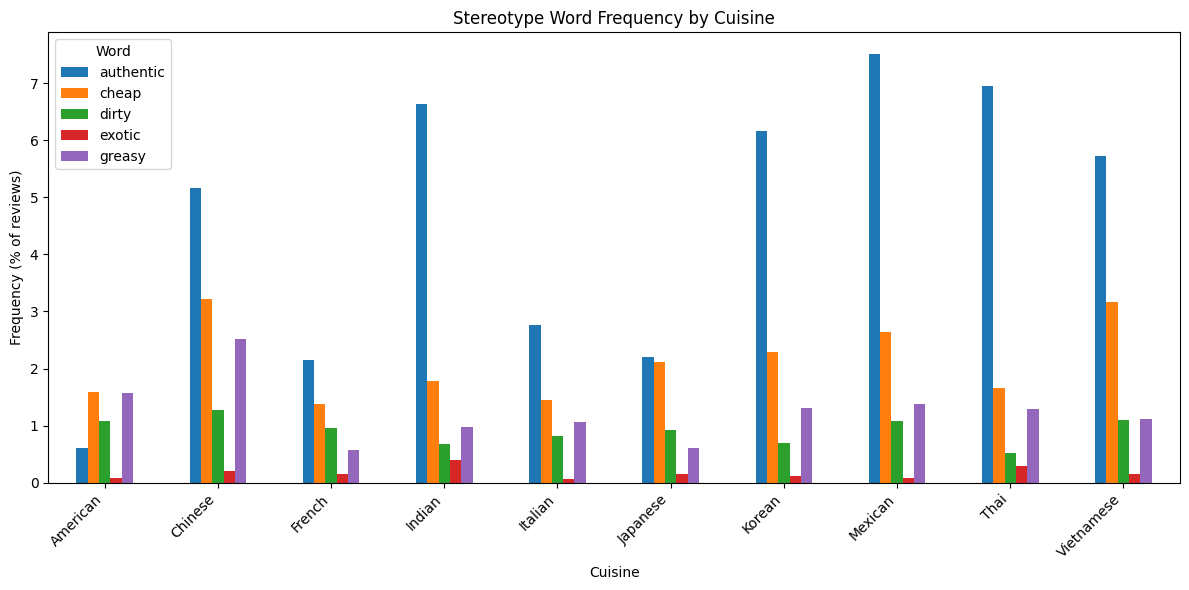

In [ ]:
# calculate chi-square tests for each stereotype word category
chi_rows = []
for category in stereotype_words:
    table = []
    for cuisine in cuisines_sorted:
        c_mask = word_df["cuisine_type"] == cuisine
        total = int(c_mask.sum())
        count = int(
            stereo_freq_df.loc[
                (stereo_freq_df["cuisine"] == cuisine)
                & (stereo_freq_df["stereotype_category"] == category),
                "count",
            ].iloc[0]
        )
        table.append([count, max(total - count, 0)])

    table = np.array(table)
    if table.sum() == 0 or table.shape[0] < 2 or table[:, 0].sum() == 0:
        chi2_stat, p_val = np.nan, np.nan
    else:
        chi2_stat, p_val, _, _ = chi2_contingency(table)

    chi_rows.append({"category": category, "chi2_stat": chi2_stat, "p_value": p_val})

chi_df = pd.DataFrame(chi_rows)
display(chi_df)

# stop words
stop_words = {
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for", "of", "with",
    "is", "was", "were", "been", "be", "have", "has", "had", "do", "does", "did", "doing",
    "am", "are", "isn", "wasn", "weren", "don", "didn", "doesn", "won", "wouldn", "shouldn",
    "can", "could", "may", "might", "must", "shall", "will", "would", "should",
    "i", "me", "my", "mine", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours",
    "yourself", "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself",
    "it", "its", "itself", "they", "them", "their", "theirs", "themselves", "this", "that", "these", "those",
    "there", "here", "where", "when", "who", "whom", "whose", "which", "what", "why", "how",
    "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "only", "own", "same",
    "so", "than", "too", "very", "really", "just", "also", "still", "even", "much", "many", "lot", "lots",
    "not", "no", "nor", "if", "then", "because", "while", "into", "onto", "over", "under", "again",
    "up", "down", "out", "off", "as", "from", "by", "about", "after", "before", "during", "through",
    "food", "restaurant", "place", "good", "great", "nice", "bad", "best", "better", "worst",
    "service", "staff", "menu", "ordered", "order", "got", "get", "came", "come", "went", "go",
    "one", "two", "three", "first", "last", "always", "never", "ever", "make", "made",
}

# extra non-informative contractions/fragments common in Yelp text tokenization
stop_words.update({"im", "ive", "id", "ill", "youre", "youve", "youll", "theyre", "theyve", "weve", "cant", "couldnt", "didnt", "doesnt", "dont", "isnt", "wasnt", "werent", "wouldnt", "shouldnt", "wont", "thats", "theres", "heres"})

# find top words for each cuisine
word_pattern = re.compile(r"[a-z]+")
top_words_map = {}
for cuisine in cuisines_sorted:
    c_text = text_series[word_df["cuisine_type"] == cuisine]
    counter = Counter()
    for t in c_text:
        tokens = word_pattern.findall(t.lower())
        tokens = [w for w in tokens if len(w) >= 3 and w not in stop_words]
        counter.update(tokens)
    top20 = counter.most_common(20)
    top_words_map[cuisine] = top20

top_words_rows = []
for cuisine, pairs in top_words_map.items():
    for rank, (word, count) in enumerate(pairs, start=1):
        top_words_rows.append({"cuisine": cuisine, "rank": rank, "word": word, "count": int(count)})

top_words_df = pd.DataFrame(top_words_rows)
display(top_words_df)

# compare word frequencies for specific words
compare_words = ["cheap", "authentic", "dirty", "exotic", "greasy"]
compare_rows = []
for cuisine in cuisines_sorted:
    c_mask = word_df["cuisine_type"] == cuisine
    total = int(c_mask.sum())
    c_text = text_series.loc[c_mask]
    for w in compare_words:
        if total == 0:
            freq = 0.0
        else:
            has = c_text.str.contains(rf"\b{re.escape(w)}\b", regex=True, case=False, na=False)
            freq = float(has.mean())
        compare_rows.append({"cuisine": cuisine, "word": w, "frequency": freq})

compare_df = pd.DataFrame(compare_rows)
plot_df = compare_df.pivot(index="cuisine", columns="word", values="frequency").fillna(0.0)

ax = (plot_df * 100).plot(kind="bar", figsize=(12, 6))
ax.set_title("Stereotype Word Frequency by Cuisine")
ax.set_xlabel("Cuisine")
ax.set_ylabel("Frequency (% of reviews)")
ax.legend(title="Word")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
